# Task 1: Data Preparation


In [1]:
#Loads the correct extentions needed for the notebook
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loads csv into a data frame
df = pd.read_csv("victorian_road_crash_data.csv")

In [3]:
# Fixes time and date issues within the dataset. if it fails it will return as a NaN
def parse_date(val):
    try:
        return pd.to_datetime(val, format='%d/%m/%Y')
    except:
        return np.nan

def parse_time(val):
    try:
        return pd.to_datetime(val, format='%H:%M:%S').time()
    except:
        return np.nan

df['ACCIDENT_DATE'] = df['ACCIDENT_DATE'].apply(parse_date)
df['ACCIDENT_TIME'] = df['ACCIDENT_TIME'].apply(parse_time)

In [4]:
#Fixing some of the missing data
# Will drop the SRNS column as it is missing a good portion of data
df = df.drop(columns=['SRNS']) 

#dropping rows with missing values in the specified columns as it is a small portion of data and not really needed if we have suburb
df = df.dropna(subset=['LATITUDE', 'LONGITUDE', 'NO_OF_VEHICLES', ])

#will fill the missing values with a unknown for caterogical data 
categorical_cols = ['ROAD_NAME', 'ROAD_TYPE', 'LGA_NAME', 'DTP_REGION', 
                    'DEG_URBAN_NAME', 'RMA', 'DIVIDED', 'STAT_DIV_NAME']
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

In [5]:
#drops the non needed vicgrid due to having lat x long
df = df.drop(columns=['VICGRID_X', 'VICGRID_Y'], errors='ignore')

# we need to keep the lat and long so itll filted out junk ones
df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])

In [6]:
# fixes up the typos and ambiguities in the dataset.
# 'Weekend' is now mapped to a unknown and thu is now corrected to thursday
day_fix = {'Thu': 'Thursday', 'Weekend': 'Unknown'}
df['DAY_OF_WEEK'] = df['DAY_OF_WEEK'].replace(day_fix)
# cleans up the bad light condition entries
light_fix = {'Unk.': 'Unknown', 'No': 'Unknown', 'Days': 'Day'}
df['LIGHT_CONDITION'] = df['LIGHT_CONDITION'].replace(light_fix)

In [7]:
# Cleans the SPEED_ZONE column and identifies if speed is unknown or other, replacing with NaN
def clean_speed(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower()

    if 'not know' in val or 'other' in val:
        return np.nan

    nums = ''.join(filter(str.isdigit, val))
    if nums:
        speed = int(nums)
        if speed > 110 or speed == 0:
            return np.nan
        return speed
    return np.nan

# Applies the cleaning function and then convert it to a integer type
df['SPEED_ZONE_NUM'] = df['SPEED_ZONE'].apply(clean_speed).astype('Int64')


In [8]:
# Convert vehicle count columns to integers (no decimals needed)
cols_to_fix = [
    'NO_OF_VEHICLES', 'HEAVYVEHICLE', 'PASSENGERVEHICLE',
    'MOTORCYCLE', 'PT_VEHICLE'
]
for col in cols_to_fix:
    df[col] = df[col].astype(int)

df['ROAD_ROUTE_1'] = df['ROAD_ROUTE_1'].fillna(0).astype(int)

In [9]:
# 5. displays that it processed correctly and then displays the first few rows to show the changes
print(f"Data successfully cleaned. ")
display(df.head())

Data successfully cleaned. 


,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,DAY_OF_WEEK,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,...,NO_OF_VEHICLES,HEAVYVEHICLE,PASSENGERVEHICLE,MOTORCYCLE,PT_VEHICLE,DEG_URBAN_NAME,RMA,DIVIDED,STAT_DIV_NAME,SPEED_ZONE_NUM
0,T20150000784,2015-01-01,17:50:00,Collision with vehicle,Thursday,163,VEHICLE STRIKES DOOR OF PARKED/STATIONARY VEHICLE,Day,No,Not at intersection,...,2,0,1,0,0,MELB_URBAN,Arterial Highway,Undivided,Metro,50
1,T20150000043,2015-01-01,19:30:00,No collision and no object struck,Thursday,184,OUT OF CONTROL ON CARRIAGEWAY (ON BEND),Dusk/Dawn,Yes,T intersection,...,1,0,0,1,0,RURAL_VICTORIA,Arterial Other,Undivided,Metro,60
2,T20150000037,2015-01-01,19:00:00,Collision with vehicle,Thursday,110,CROSS TRAFFIC(INTERSECTIONS ONLY),Dusk/Dawn,Yes,Cross intersection,...,2,0,1,0,0,MELB_URBAN,Arterial Other,Divided,Metro,60
3,T20150000008,2015-01-01,00:10:00,Collision with vehicle,Thursday,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,...,2,0,0,2,0,RURAL_VICTORIA,Unknown,Unknown,Country,100
4,T20150000050,2015-01-01,04:00:00,Struck Pedestrian,Thursday,109,ANY MANOEUVRE INVOLVING PED NOT INCLUDED IN DC...,Dark No street lights,Yes,Not at intersection,...,1,0,1,0,0,RURAL_VICTORIA,Local Road,Undivided,Country,50


In [10]:
df.to_csv('cleaned.csv', index=False)

# Task 2: Data Exploration

## Task 2.1 

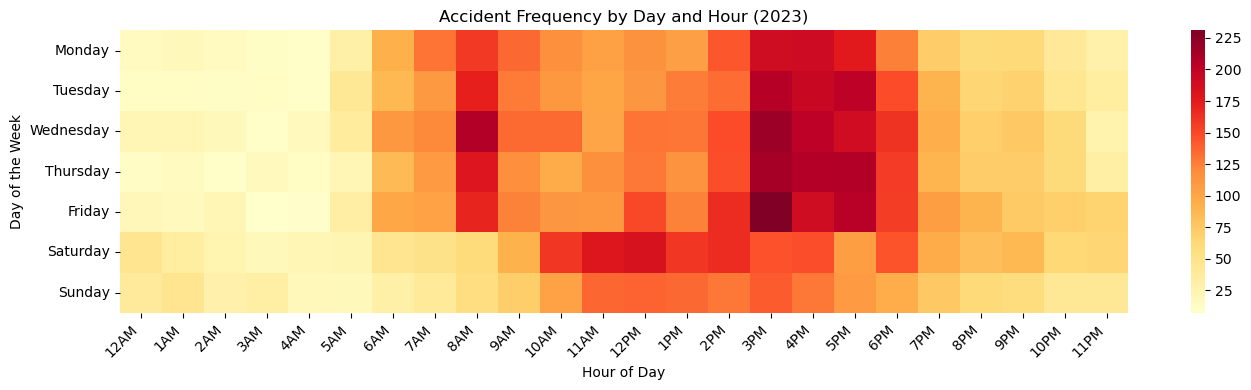

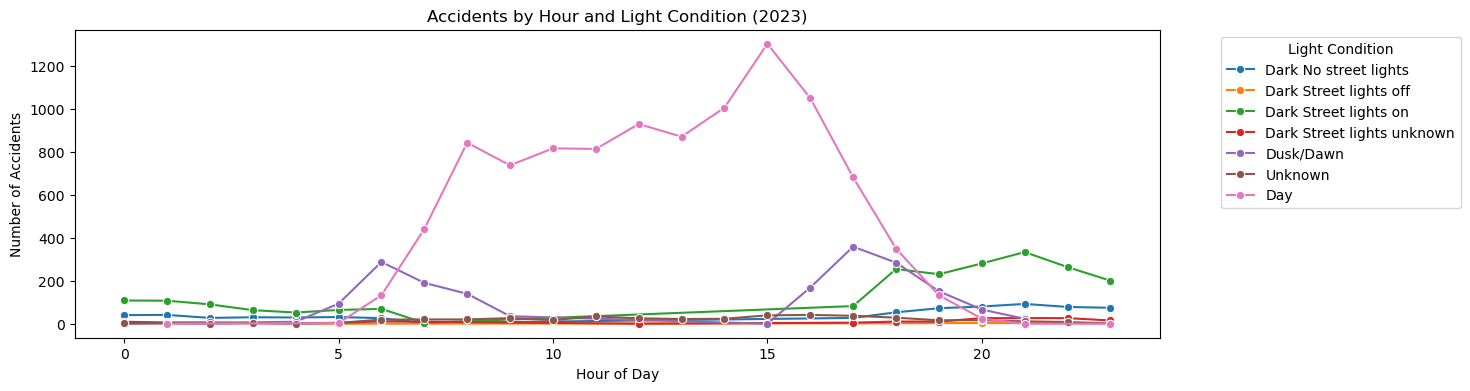

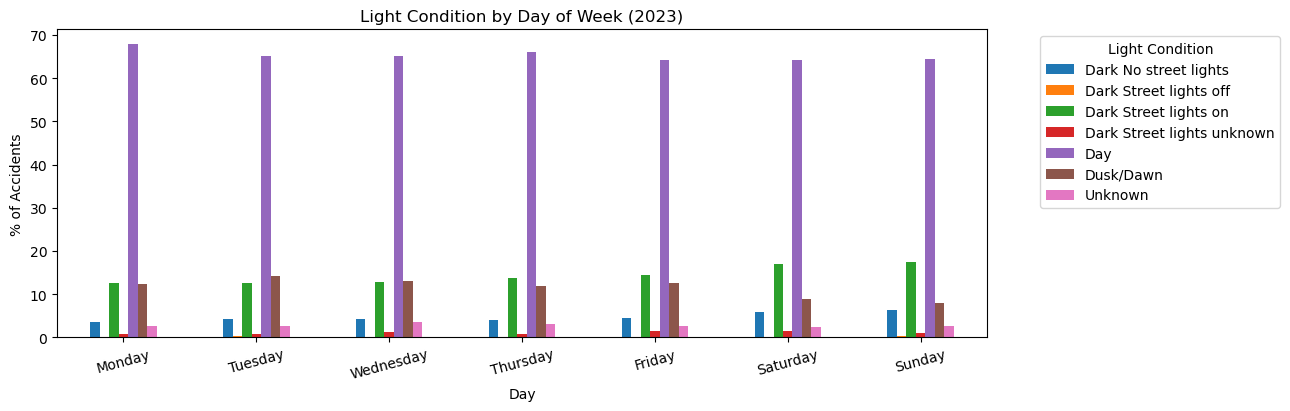

In [11]:
# Filters for 2023 data only
df_2023 = df[df['ACCIDENT_DATE'].dt.year == 2023].copy()

# Correct format for HH:MM:SS
df_2023['ACCIDENT_TIME'] = pd.to_datetime(df_2023['ACCIDENT_TIME'].astype(str), format='%H:%M:%S')
df_2023['HOUR'] = df_2023['ACCIDENT_TIME'].dt.hour

# sets the correct Day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Heatmap data
heatmap_data = df_2023.groupby(['DAY_OF_WEEK', 'HOUR']).size().unstack(fill_value=0).reindex(day_order)

hour_labels = [f"{h % 12 or 12}{'AM' if h < 12 else 'PM'}" for h in range(24)]

plt.figure(figsize=(14, 4))
sns.heatmap(heatmap_data, cmap='YlOrRd', xticklabels=hour_labels)
plt.xticks(rotation=45, ha='right')
plt.title('Accident Frequency by Day and Hour (2023)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of the Week')
plt.tight_layout()
plt.show()

# Dotted line graph of light conditions in 2023
light_hour = df_2023.groupby(['HOUR', 'LIGHT_CONDITION']).size().reset_index(name='COUNT')

plt.figure(figsize=(14, 4))
sns.lineplot(data=light_hour, x='HOUR', y='COUNT', hue='LIGHT_CONDITION', marker='o')
plt.title('Accidents by Hour and Light Condition (2023)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.legend(title='Light Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Crashes based on time of day 
light_day = df_2023.groupby(['DAY_OF_WEEK', 'LIGHT_CONDITION']).size().unstack(fill_value=0).reindex(day_order)
light_day_pct = light_day.div(light_day.sum(axis=1), axis=0) * 100

light_day_pct.plot(kind='bar', figsize=(12, 4))
plt.title('Light Condition by Day of Week (2023)')
plt.xlabel('Day')
plt.ylabel('% of Accidents')
plt.xticks(rotation=15)
plt.legend(title='Light Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Task 2.2 

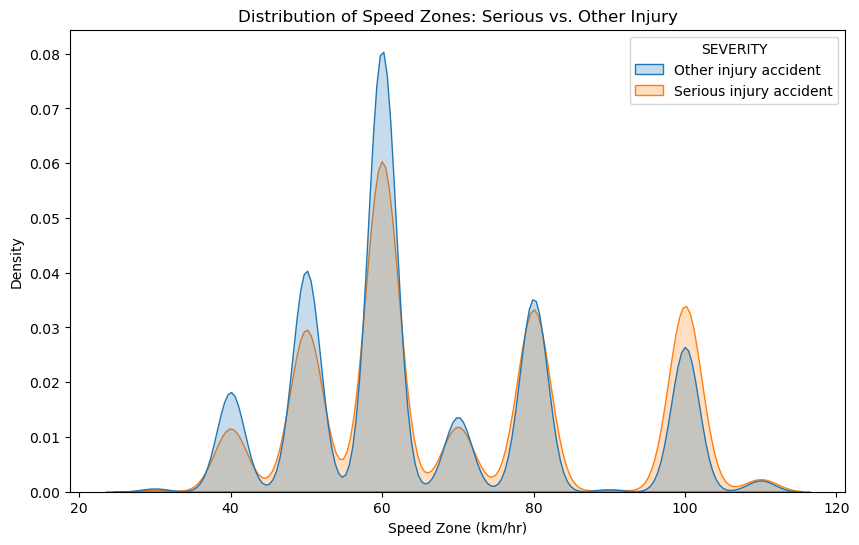

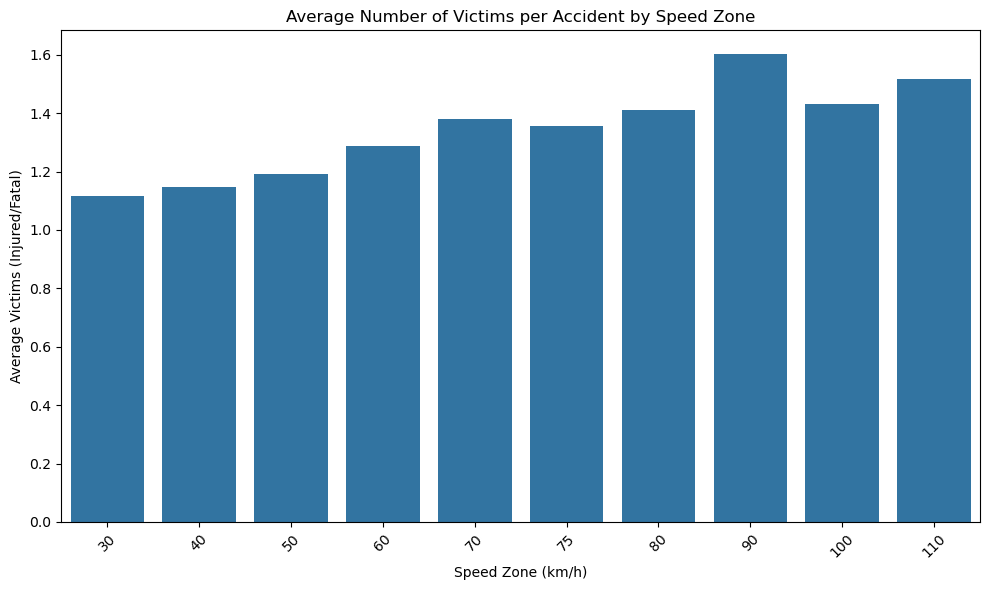

In [12]:
# Filter for serious and other injury accidents only
severity_df = df[df['SEVERITY'].isin(['Serious injury accident', 'Other injury accident'])]

# Distribution Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=severity_df, x='SPEED_ZONE_NUM', hue='SEVERITY', fill=True, common_norm=False)
plt.title('Distribution of Speed Zones: Serious vs. Other Injury')
plt.xlabel('Speed Zone (km/hr)')
plt.ylabel('Density')
plt.show()

# Average number of victims per accident by speed zone
#Groups by speed zone and then calculates the mean of INJ_OR_FATAL, then sorts by the speed zone for the plot
speed_avg = (
    df.dropna(subset=['SPEED_ZONE_NUM'])
    .groupby('SPEED_ZONE_NUM', observed=True)['INJ_OR_FATAL']
    .mean()
    .reset_index()
    .sort_values('SPEED_ZONE_NUM')
)
plt.figure(figsize=(10, 6))
sns.barplot(data=speed_avg, x='SPEED_ZONE_NUM', y='INJ_OR_FATAL', order=speed_avg['SPEED_ZONE_NUM'])
plt.title('Average Number of Victims per Accident by Speed Zone')
plt.xlabel('Speed Zone (km/h)')
plt.ylabel('Average Victims (Injured/Fatal)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 2.3 

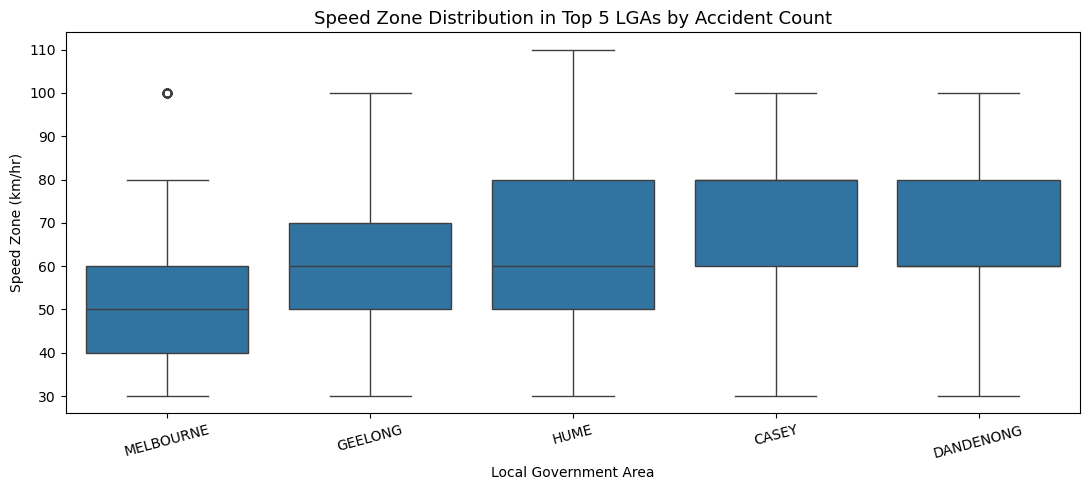

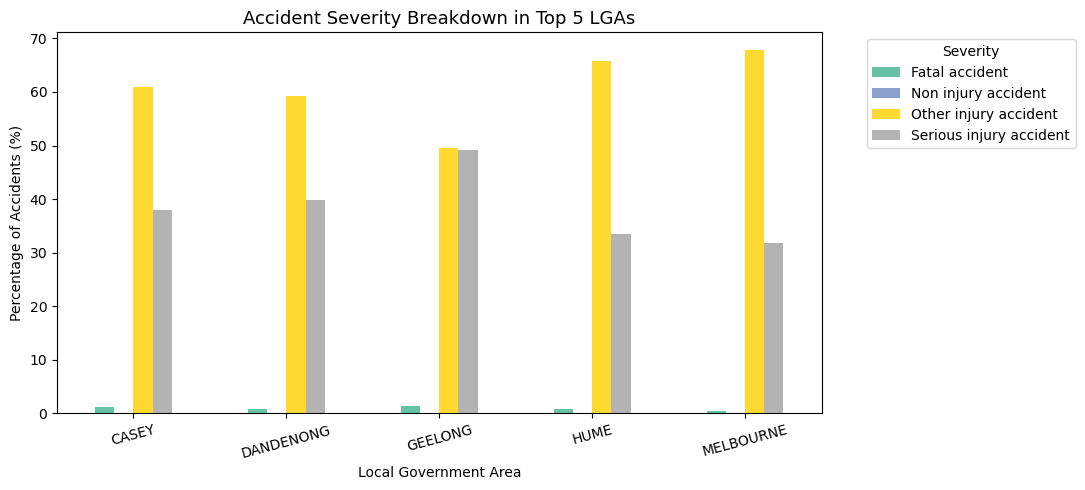

In [13]:
# Identifies the top 5 LGAs by total accident count
top_5_lgas = df['LGA_NAME'].value_counts().nlargest(5).index
df_top5 = df[df['LGA_NAME'].isin(top_5_lgas)].copy()

# Boxplot of speed zones across the top 5 LGAs
plt.figure(figsize=(11, 5))
sns.boxplot(data=df_top5, x='LGA_NAME', y='SPEED_ZONE_NUM')
plt.title('Speed Zone Distribution in Top 5 LGAs by Accident Count', fontsize=13)
plt.xlabel('Local Government Area')
plt.ylabel('Speed Zone (km/hr)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Accident severity breakdown in the top 5 LGAs 
severity_counts = df_top5.groupby(['LGA_NAME', 'SEVERITY']).size().unstack(fill_value=0)
severity_pct = severity_counts.div(severity_counts.sum(axis=1), axis=0) * 100

severity_pct.plot(kind='bar', figsize=(11, 5), colormap='Set2')
plt.title('Accident Severity Breakdown in Top 5 LGAs', fontsize=13)
plt.xlabel('Local Government Area')
plt.ylabel('Percentage of Accidents (%)')
plt.xticks(rotation=15)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()